# Partition distribution & mergeability — optimized DP2 builds

Analysis of the partitioning of three size-optimized `hats-import` builds of DP2 object
data (partial-sky test regions under `/sdf/data/rubin/user/olynn/mem_size_dp2/`), built to
a **target maximum partition size of 1 GB in-memory**. **Gaia DR3** is the benchmark
catalog throughout. The heavy machinery lives in [`partition_stats.py`](partition_stats.py).

| catalog | partitions | rows | sky fraction | orders | arrow total |
|---|---|---|---|---|---|
| optimized_0 | 271 | 10.4M | 0.23% | 4–8 | 113.5 GB |
| optimized_1 | 118 | 12.6M | 1.11% | 3–7 | 40.1 GB |
| optimized_2 | 294 | 54.8M | 0.99% | 4–6 | 125.6 GB |

### Three notions of "partition size"

Data inflates twice on the way from disk to RAM — decompression (~1.4–1.5× here), then
decoding of parquet's dictionary/RLE pages into plain arrow buffers (another ~1.5–2×):

| measure | function | cost |
|---|---|---|
| on-disk compressed bytes | `partition_sizes` | one `os.stat` per file |
| rows + parquet-uncompressed bytes | `partition_frame` | one `_metadata` read |
| **exact arrow in-memory bytes** (`Table.nbytes`) | `partition_arrow_mb` | full read of every file (cached) |

The 1 GB budget is an *in-memory* budget, so mergeability must be judged with
`partition_arrow_mb` — the cheap proxies understate RAM by 1.5–3× and wildly overstate
how much could be merged (they suggested 40–67% over-splitting; the true number is 4–10%).
Scans are cached in `.partition_cache/` next to this notebook, so everything below runs in
seconds.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import partition_stats as ps

ps.quiet()  # silence third-party log spam + benign hats plot warning
%matplotlib inline
plt.rcParams.update({"font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14})

MEM_ROOT = "/sdf/data/rubin/user/olynn/mem_size_dp2"
CATALOGS = {f"optimized_{i}": f"{MEM_ROOT}/optimized_{i}/optimized_{i}" for i in range(3)}
GAIA = "/sdf/data/rubin/cosmicdata/lsdb/gaia_dr3/gaia"  # benchmark

MERGE_THRESH_MB = 1000.0  # build target: max partition size, in-memory

# Partition size distributions (on disk)

Histograms of on-disk compressed parquet bytes per partition. Sizes come from stat-ing
each partition's deterministic path, so `_metadata`, skymaps and thumbnails are excluded.

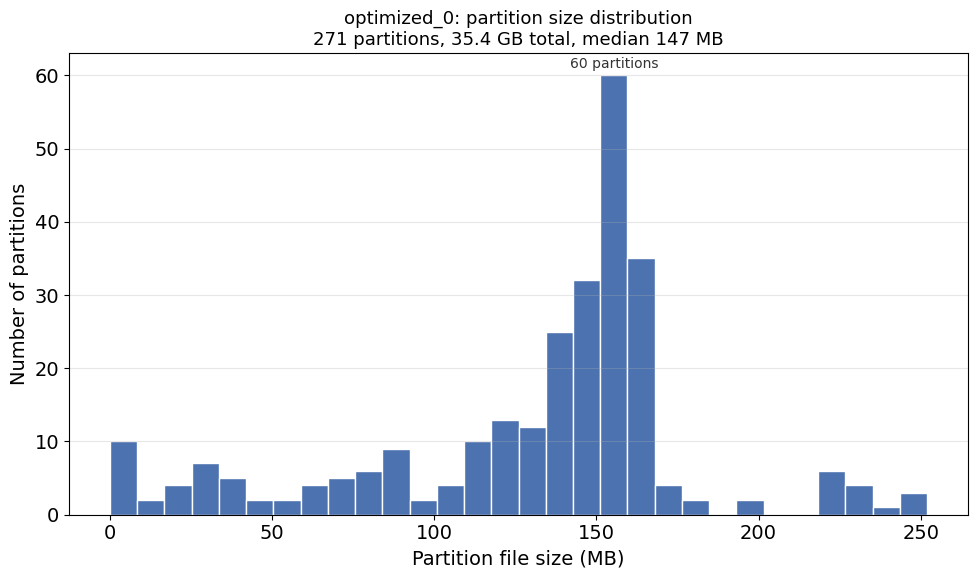

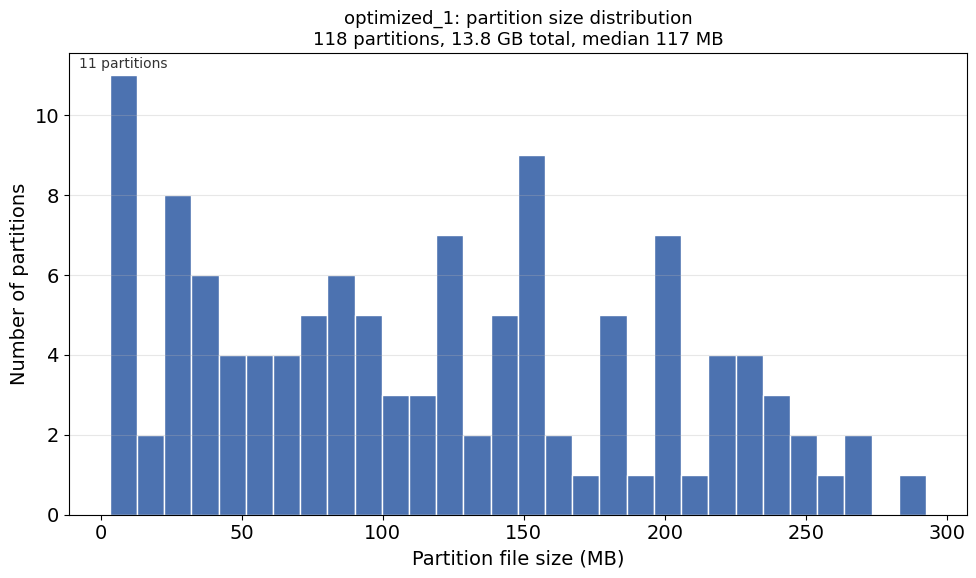

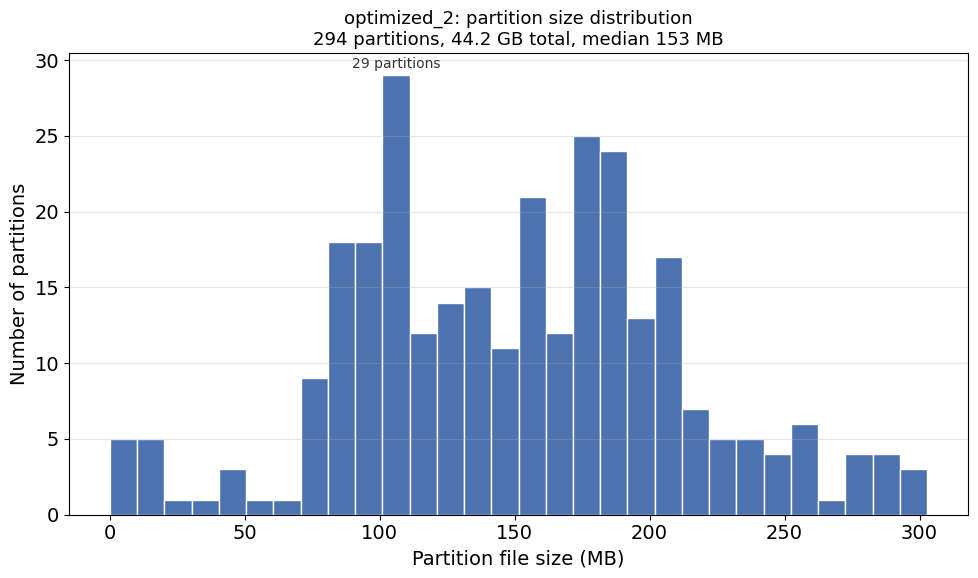

In [2]:
for name, path in CATALOGS.items():
    ps.plot_partition_hist(name, path)

# Where partition-size extremes sit on the sky

The 20 largest and 20 smallest partitions (by on-disk bytes) over each footprint. The
footprints cover ≲1% of the sky, so the scatter uses RA/Dec axes centred on the footprint
(RA re-centred via the circular mean, so optimized_2 — which straddles RA = 0° — stays
contiguous). Grey points are the remaining partitions.

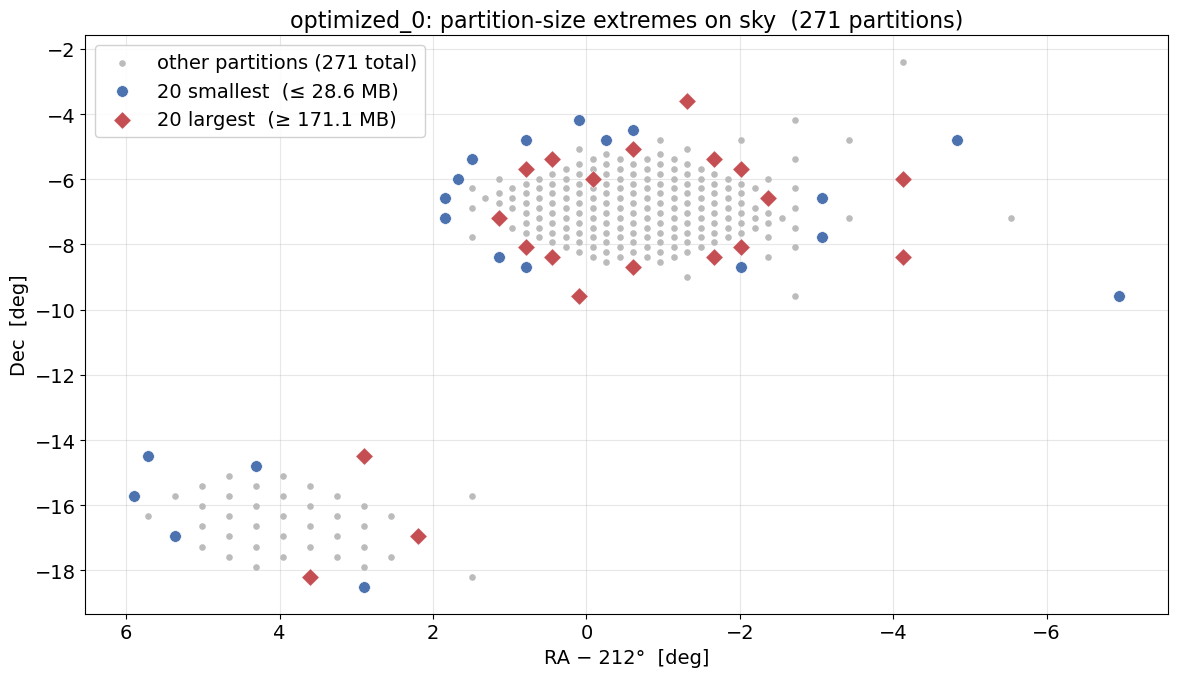

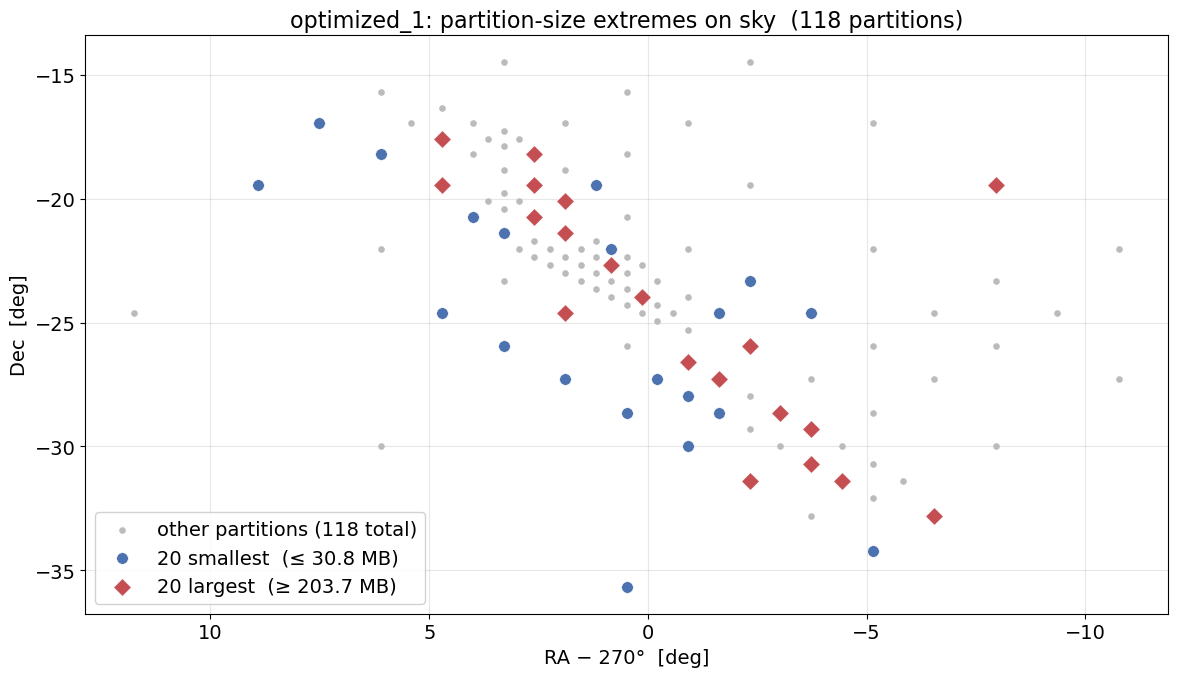

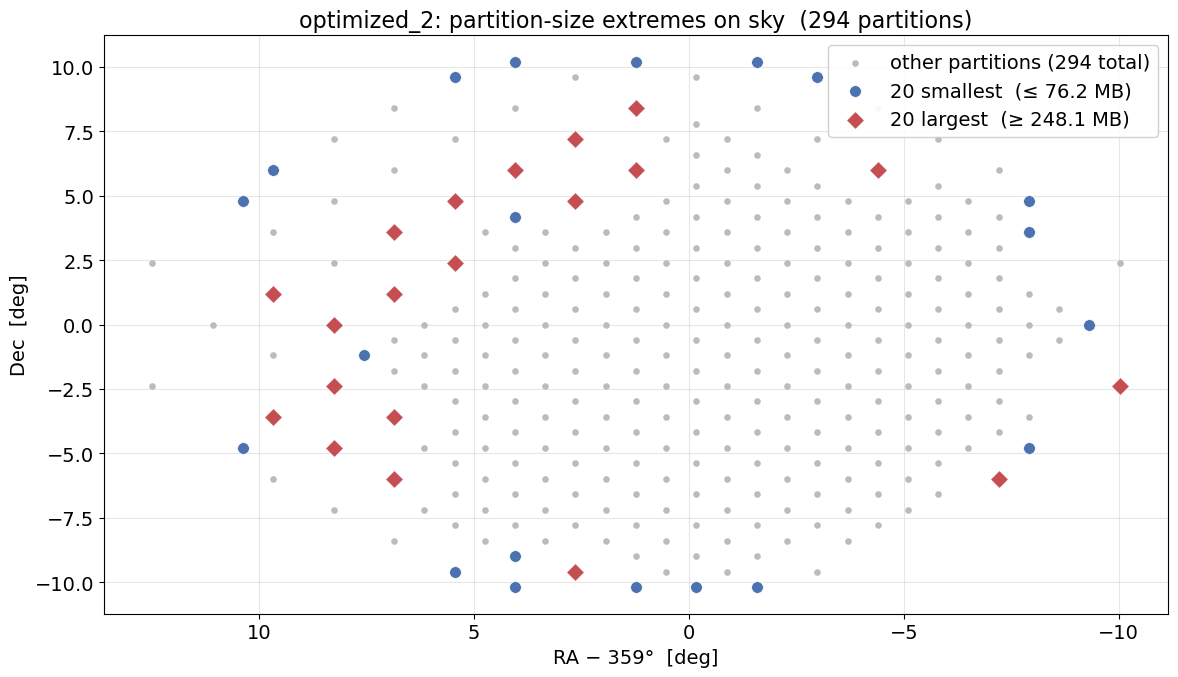

In [3]:
for name, path in CATALOGS.items():
    ps.plot_extremes_on_sky(name, path)

# Native partition maps (tile renderer) + Gaia comparison

Real HEALPix tiles coloured by per-partition **row count**, via `hats`'s
`plot_healpix_map` (int64 `ipix`/`depth` avoids the uint64-specific hats#703 crash).
Gaia is full-sky (Mollweide); the optimized footprints auto-zoom (TAN projection).

Note the builds' `hats_max_rows = 1,000,000` cap never binds — no partition exceeds
~558k rows; the 1 GB in-memory size target is the active constraint.

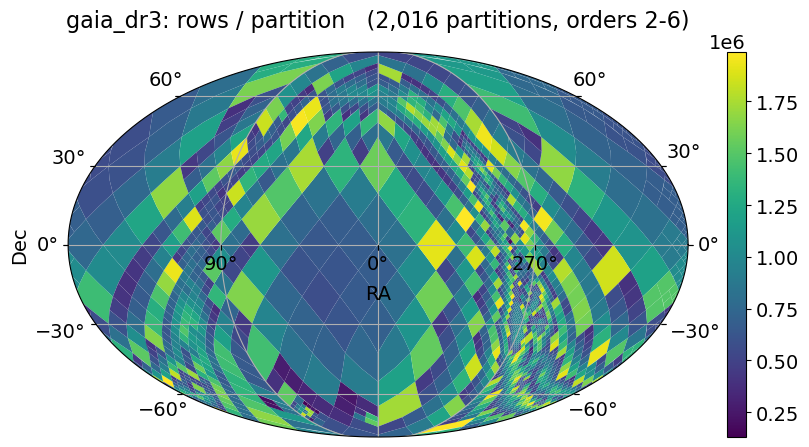

In [4]:
# Gaia DR3 benchmark — full sky (~7 s cold, instant cached).
_ = ps.plot_partition_map("gaia_dr3", GAIA, by="rows")

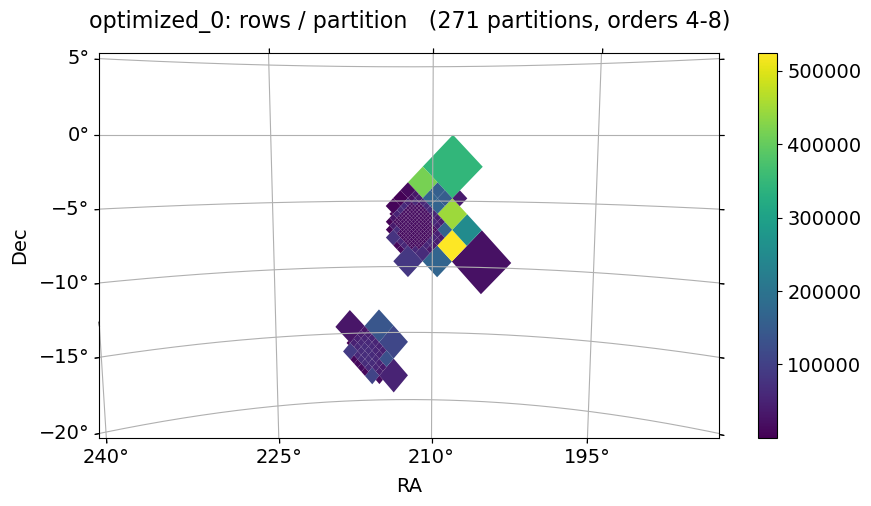

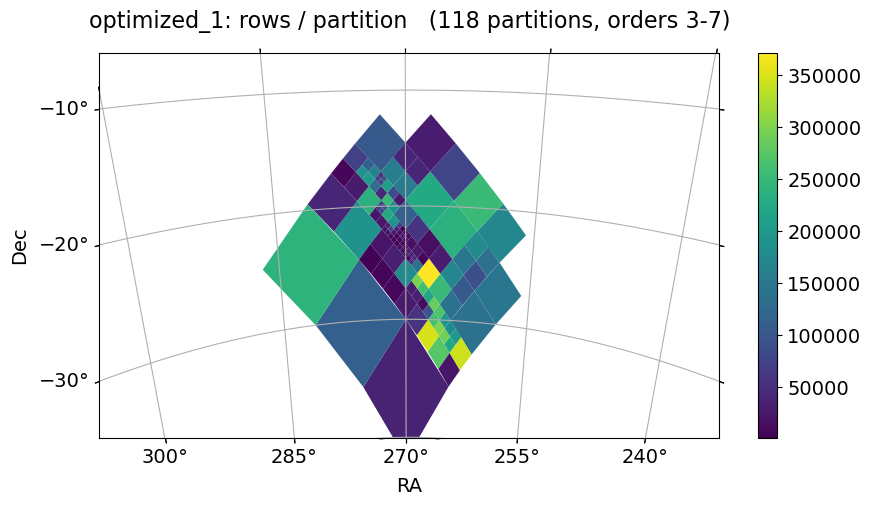

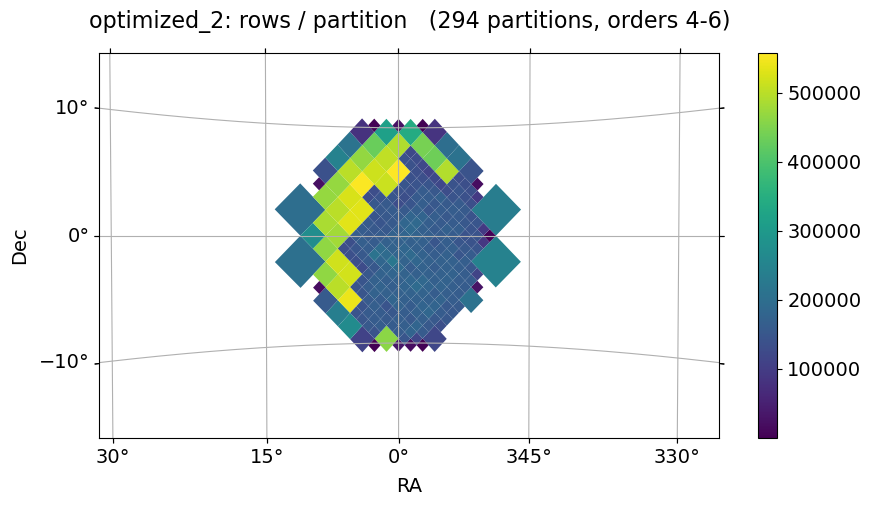

In [5]:
for name, path in CATALOGS.items():
    _ = ps.plot_partition_map(name, path, by="rows")

# Gaia partition-size distribution (vs optimized builds)

On-disk bytes per partition for Gaia DR3, and PDF overlays against the optimized builds.
Per catalog: dotted line = median, dashed line = max/4 — the size a partition would have
after one more HEALPix split (4 children), where an upper-edge dropoff is expected.

Headline: Gaia partitions are chunkier — median **335 MB** across **2,016** partitions,
vs ~**120–150 MB** medians for the optimized builds. The optimized builds' ~300 MB
on-disk ceiling is the compressed shadow of their 1 GB in-memory target.

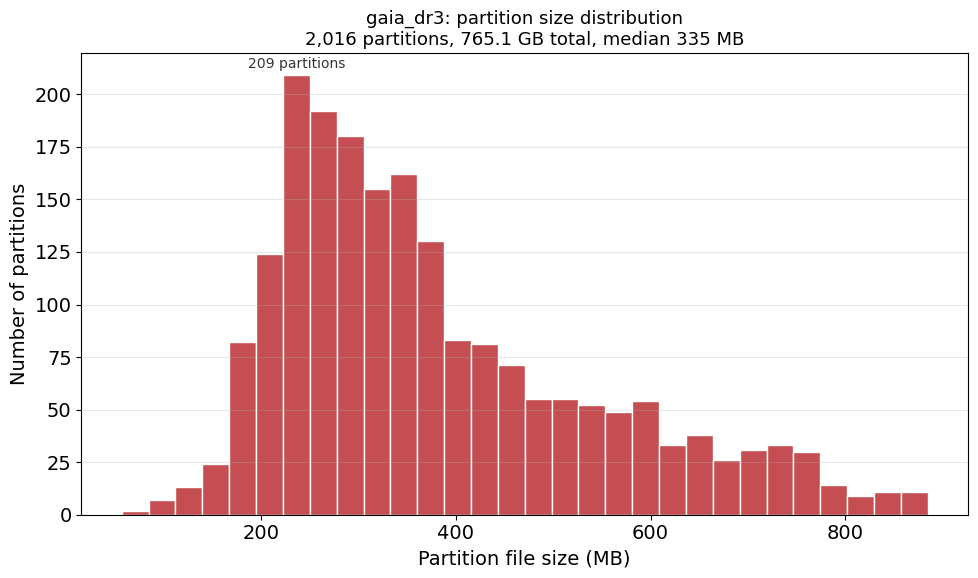

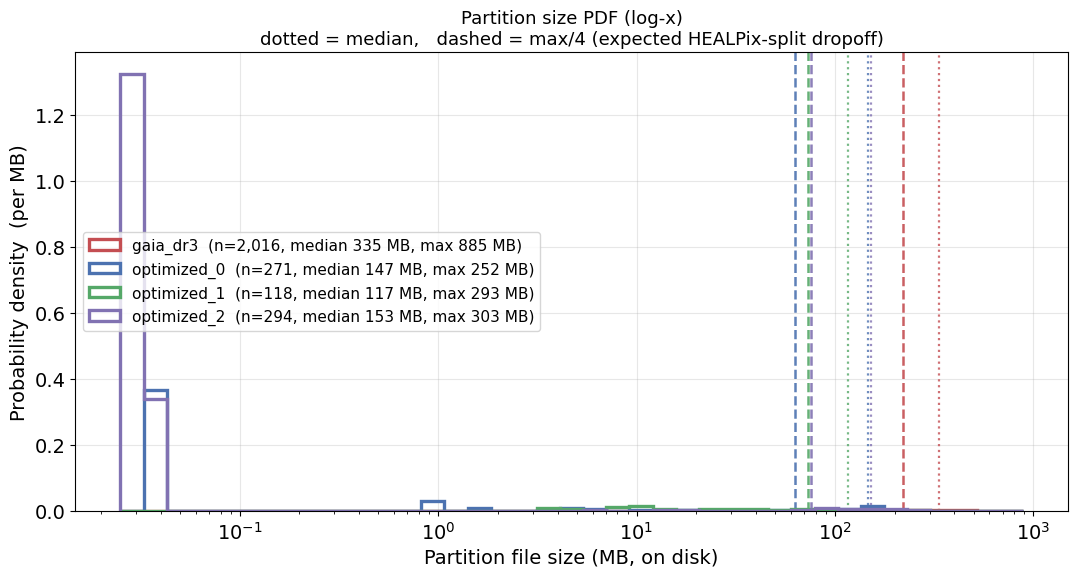

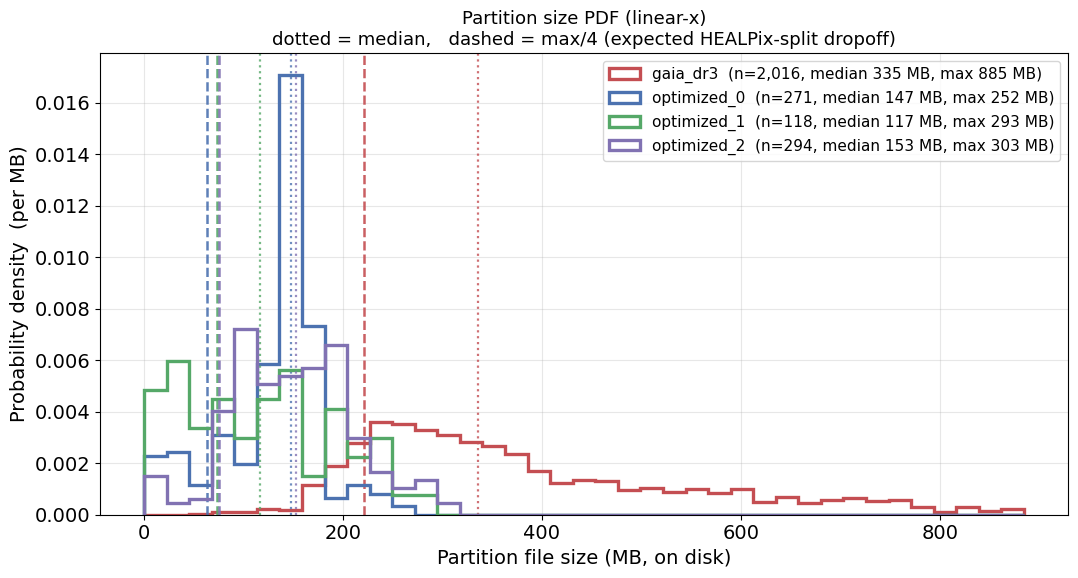

catalog                  n      total     median       mean        max      max/4
gaia_dr3             2,016   765.1 GB     335 MB     379 MB     885 MB     221 MB
optimized_0            271    35.4 GB     147 MB     131 MB     252 MB      63 MB
optimized_1            118    13.8 GB     117 MB     117 MB     293 MB      73 MB
optimized_2            294    44.2 GB     153 MB     150 MB     303 MB      76 MB


In [6]:
overlay = {"gaia_dr3": ps.ondisk_mb(GAIA)}
overlay.update({name: ps.ondisk_mb(path) for name, path in CATALOGS.items()})
colors = {"gaia_dr3": "#C44E52", "optimized_0": "#4C72B0",
          "optimized_1": "#55A868", "optimized_2": "#8172B2"}

ps.plot_partition_hist("gaia_dr3", GAIA, color=colors["gaia_dr3"])
ps.plot_size_pdf_overlay(overlay, colors, "log")
ps.plot_size_pdf_overlay(overlay, colors, "linear")
ps.print_size_table(overlay)

# Partition size split by HEALPix order

If partitioning were a fixed-order grid, each step to a finer order would cut pixel area
(and partition size) by 4×, so per-order size histograms would sit ~4× apart. A
size-targeted builder instead picks a finer order exactly where the sky is denser,
cancelling the ÷4 area step with ×4 density — flat per-order medians are its signature
(Gaia shows this clearly at ~270–395 MB across orders 2–6). The printed consecutive
median ratios make the comparison explicit: 4.0× = fixed grid, ~1× = size-targeted.

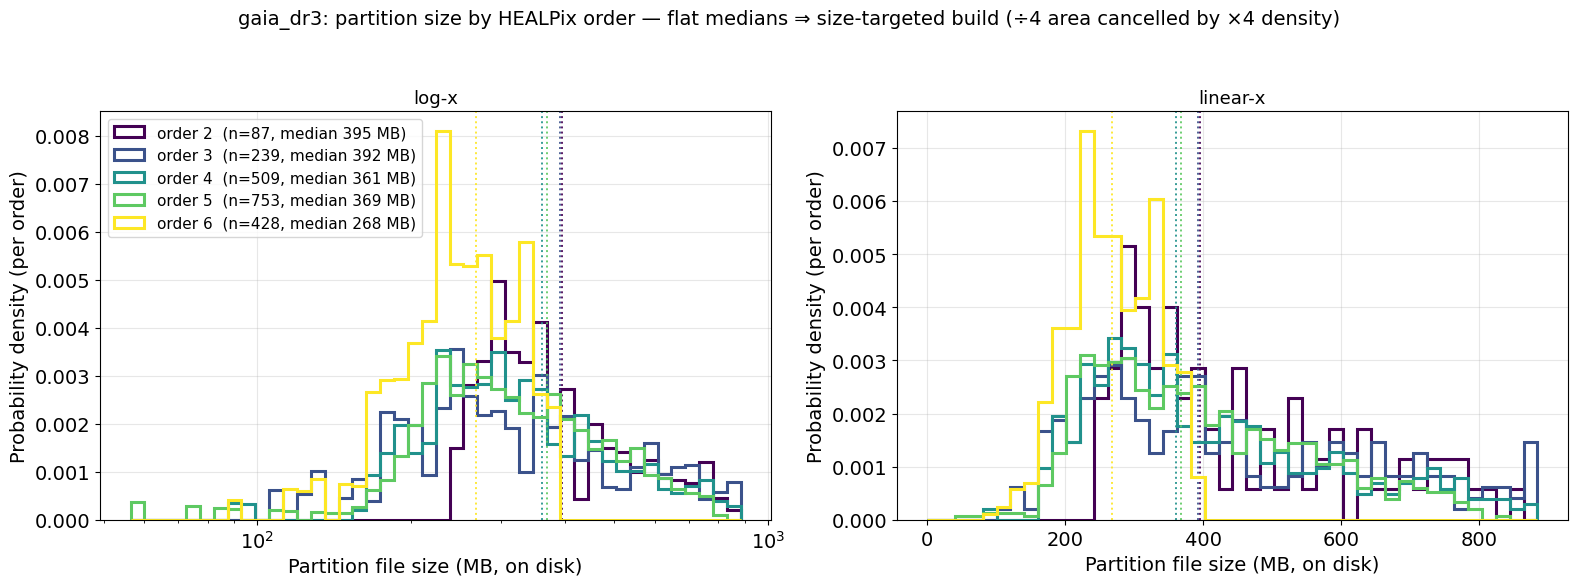

gaia_dr3: consecutive median ratios (order o / o+1) = 1.0x, 1.1x, 1.0x, 1.4x   (4.0x = fixed-grid expectation)


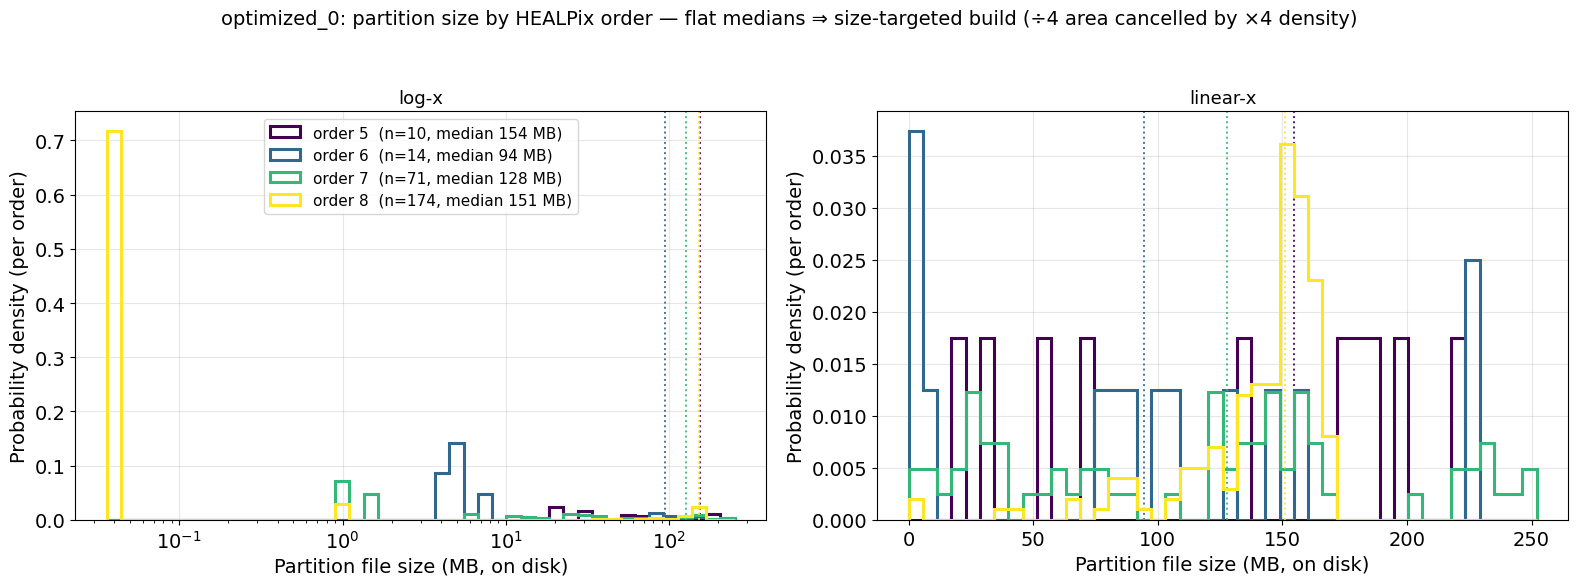

optimized_0: consecutive median ratios (order o / o+1) = 1.6x, 0.7x, 0.8x   (4.0x = fixed-grid expectation)


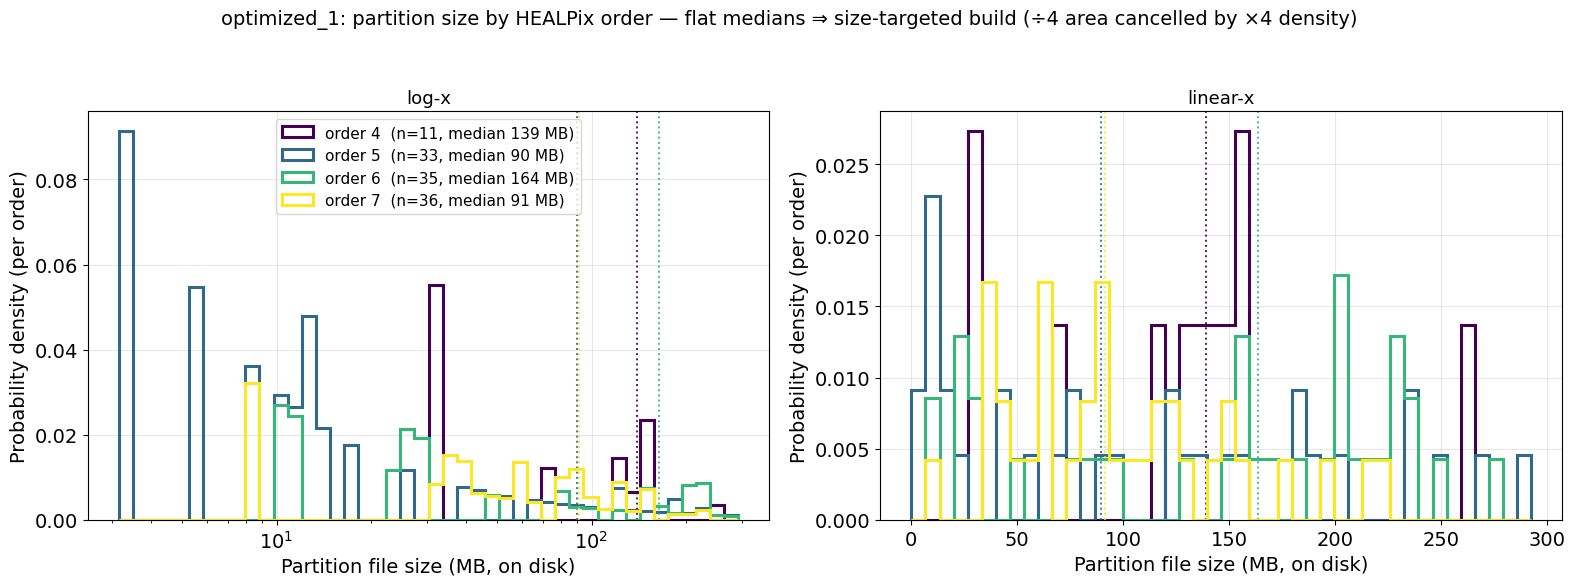

optimized_1: consecutive median ratios (order o / o+1) = 1.5x, 0.5x, 1.8x   (4.0x = fixed-grid expectation)


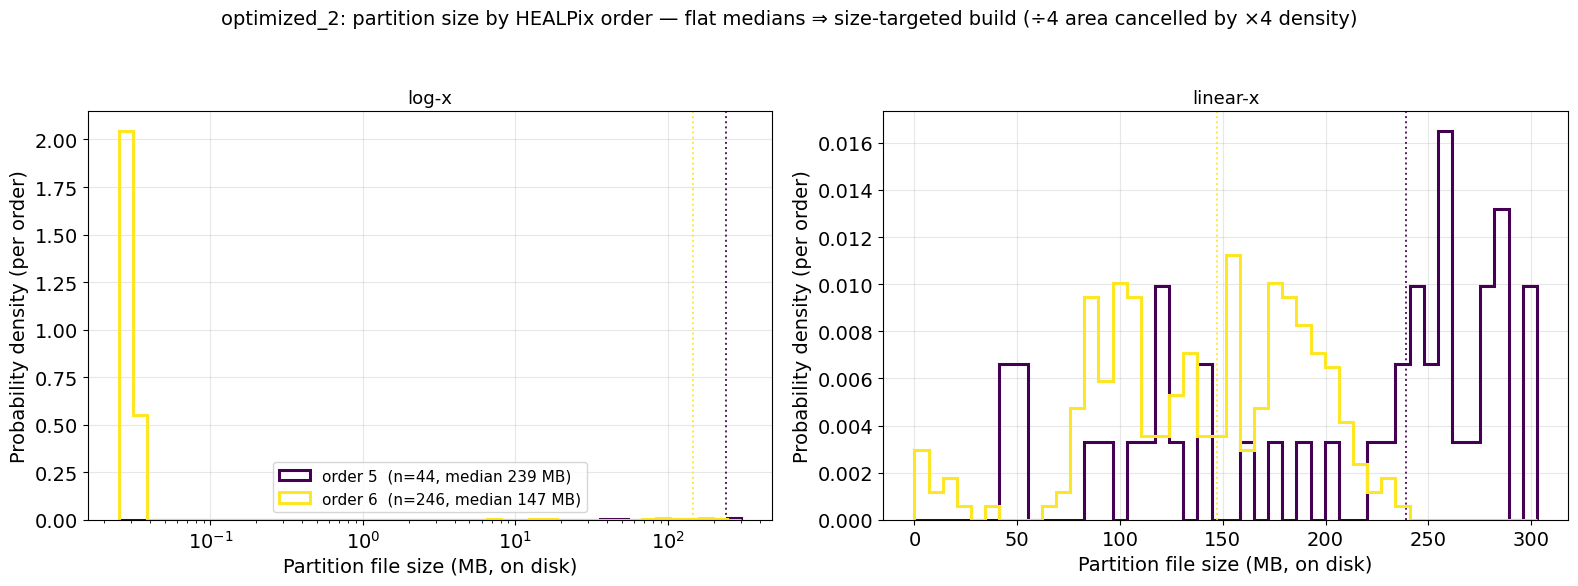

optimized_2: consecutive median ratios (order o / o+1) = 1.6x   (4.0x = fixed-grid expectation)


In [7]:
ps.plot_size_by_order("gaia_dr3", GAIA)
for name, path in CATALOGS.items():
    ps.plot_size_by_order(name, path)

# Over-split partitions: what could be aggregated to a coarser order?

Using HEALPix nesting (a pixel's parent one order coarser is `npix // 4`, NESTED),
`ps.rollup` accumulates every partition into its ancestor subtrees and
`ps.maximal_merge_groups` finds the **coarsest** subtree whose combined size stays under
the **1 GB in-memory** build target. Each such subtree holds >1 partition that could
collapse into a single coarser one without exceeding the budget.

Sizes are **exact in-memory sizes** (`Table.nbytes` via `partition_arrow_mb`); summing
children is the right merge estimate since concatenating arrow tables is essentially
exact. Using the cheap proxies here badly overstates mergeability (see intro).

optimized_0: 271 partitions, threshold 1000 MB (arrow in-memory)
  4 maximal merge groups -> eliminate 12 partitions (4.4%) -> new count 259

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  6  npix      44755 :    4 -> 1   (   881 MB)
    order  7  npix     102870 :    4 -> 1   (   878 MB)
    order  6  npix      25894 :    4 -> 1   (   971 MB)
    order  6  npix      25716 :    4 -> 1   (   872 MB)


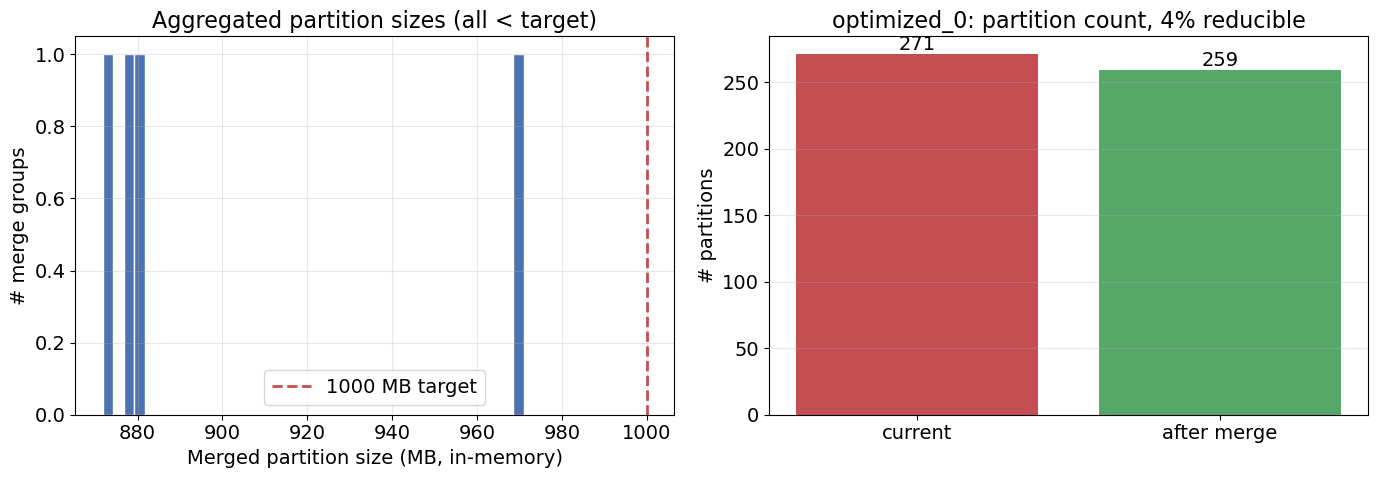

optimized_1: 118 partitions, threshold 1000 MB (arrow in-memory)
  3 maximal merge groups -> eliminate 9 partitions (7.6%) -> new count 109

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  6  npix      29091 :    4 -> 1   (   954 MB)
    order  6  npix      28916 :    4 -> 1   (   987 MB)
    order  6  npix      28913 :    4 -> 1   (   943 MB)


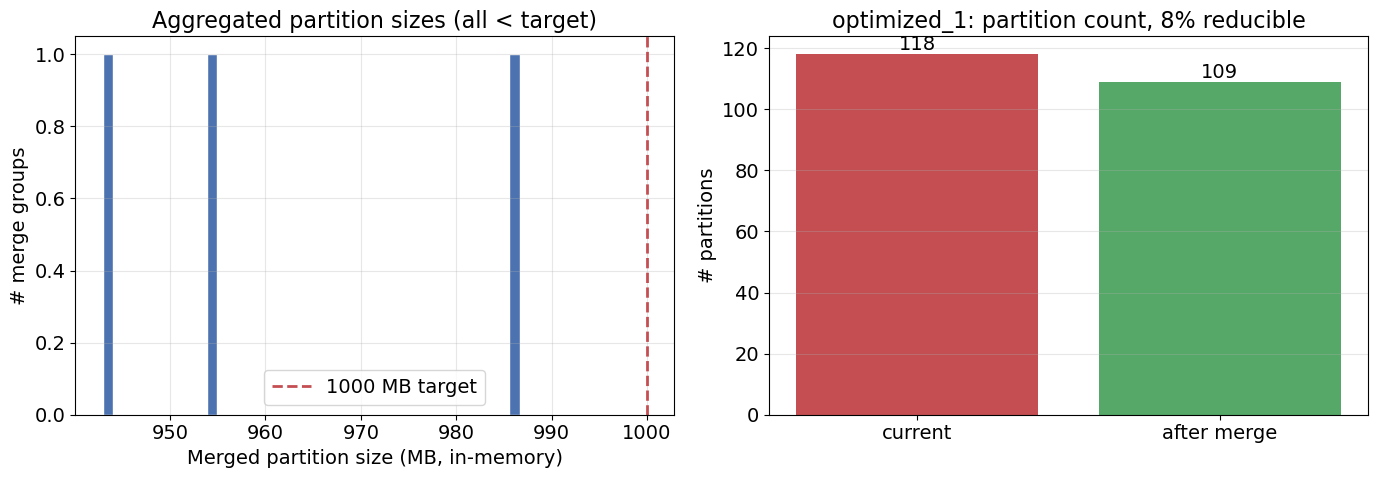

optimized_2: 294 partitions, threshold 1000 MB (arrow in-memory)
  10 maximal merge groups -> eliminate 28 partitions (9.5%) -> new count 266

  top 15 candidates (parent order/npix : #partitions -> 1, merged size):
    order  5  npix       4515 :    4 -> 1   (   905 MB)
    order  5  npix       4521 :    4 -> 1   (   979 MB)
    order  5  npix       4325 :    4 -> 1   (   980 MB)
    order  5  npix       4875 :    4 -> 1   (   922 MB)
    order  5  npix       4315 :    4 -> 1   (   905 MB)
    order  5  npix       4868 :    4 -> 1   (   917 MB)
    order  5  npix       4514 :    4 -> 1   (   996 MB)
    order  5  npix       4318 :    4 -> 1   (   967 MB)
    order  5  npix       4878 :    4 -> 1   (   893 MB)
    order  5  npix       4332 :    2 -> 1   (   985 MB)


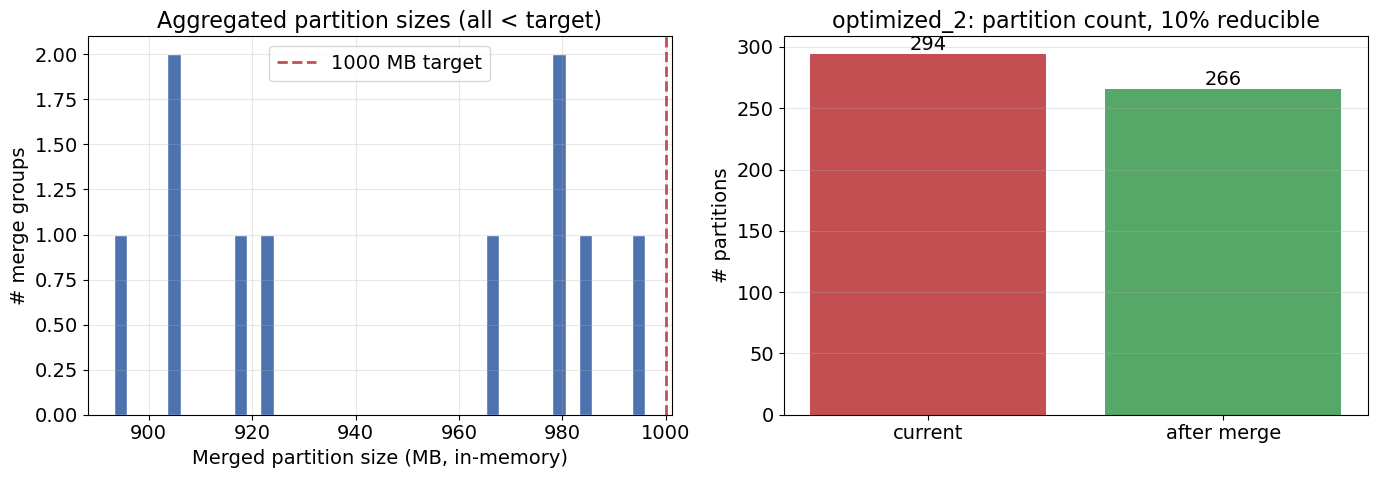

In [8]:
for name, path in CATALOGS.items():
    _ = ps.merge_candidates(name, path, thresh_mb=MERGE_THRESH_MB)

## Aggregation depth — can you merge more than once?

The roll-up already goes to **convergence**: it picks the *coarsest* ancestor still under
the threshold, and since subtree size grows monotonically up the tree, re-running finds
nothing new. "Merging twice" shows up as groups whose collapse spans **≥2 HEALPix order
levels** (depth = deepest child order − parent order). The figures show each catalog's
partition-size distribution before vs after aggregation.

optimized_0: aggregation depth (HEALPix levels collapsed):
   1 level(s): 4 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  6 npix     44755 : depth 1     4 -> 1  (  881 MB, child orders up to 7)
     order  7 npix    102870 : depth 1     4 -> 1  (  878 MB, child orders up to 8)
     order  6 npix     25894 : depth 1     4 -> 1  (  971 MB, child orders up to 7)
     order  6 npix     25716 : depth 1     4 -> 1  (  872 MB, child orders up to 7)


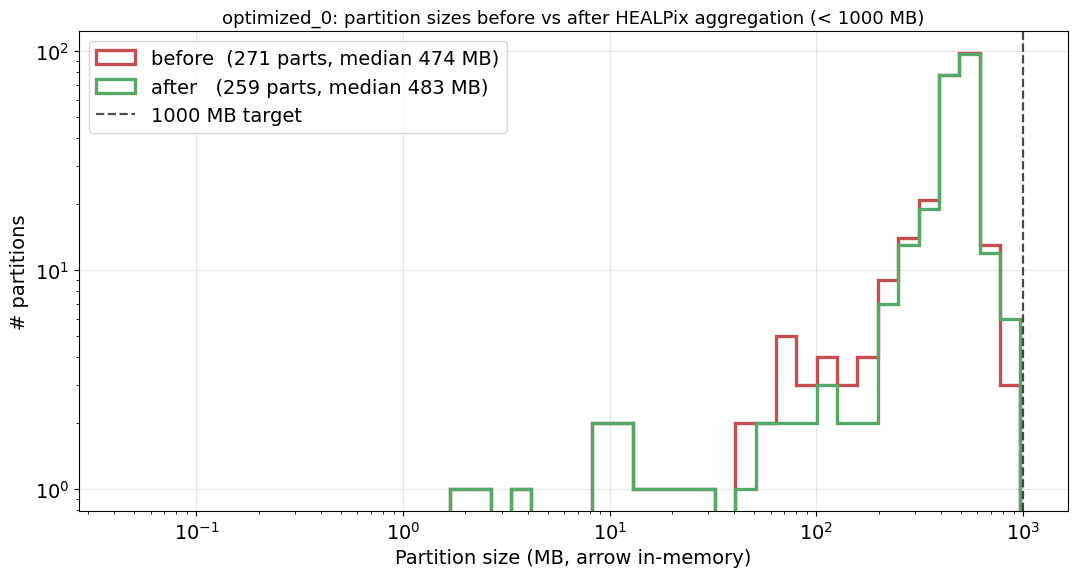

optimized_1: aggregation depth (HEALPix levels collapsed):
   1 level(s): 3 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  6 npix     29091 : depth 1     4 -> 1  (  954 MB, child orders up to 7)
     order  6 npix     28916 : depth 1     4 -> 1  (  987 MB, child orders up to 7)
     order  6 npix     28913 : depth 1     4 -> 1  (  943 MB, child orders up to 7)


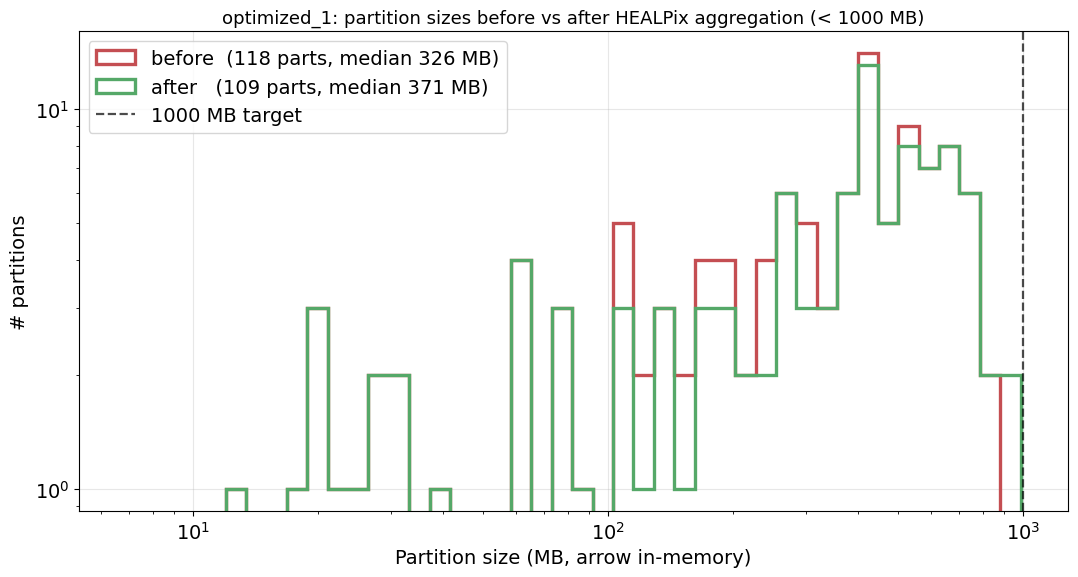

optimized_2: aggregation depth (HEALPix levels collapsed):
   1 level(s): 10 groups
   -> 0 groups aggregate >=2 levels ('twice or more')

   deepest examples (parent order/npix : depth, #parts -> 1, size):
     order  5 npix      4515 : depth 1     4 -> 1  (  905 MB, child orders up to 6)
     order  5 npix      4521 : depth 1     4 -> 1  (  979 MB, child orders up to 6)
     order  5 npix      4325 : depth 1     4 -> 1  (  980 MB, child orders up to 6)
     order  5 npix      4875 : depth 1     4 -> 1  (  922 MB, child orders up to 6)
     order  5 npix      4315 : depth 1     4 -> 1  (  905 MB, child orders up to 6)
     order  5 npix      4868 : depth 1     4 -> 1  (  917 MB, child orders up to 6)
     order  5 npix      4514 : depth 1     4 -> 1  (  996 MB, child orders up to 6)
     order  5 npix      4318 : depth 1     4 -> 1  (  967 MB, child orders up to 6)
     order  5 npix      4878 : depth 1     4 -> 1  (  893 MB, child orders up to 6)
     order  5 npix      4332 : depth 

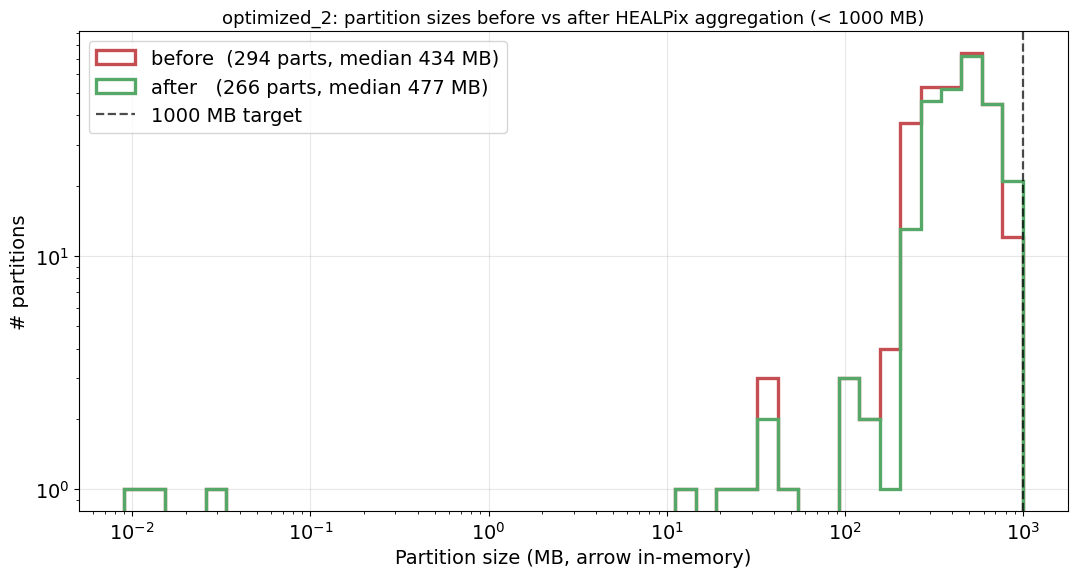

In [9]:
for name, path in CATALOGS.items():
    _ = ps.aggregation_report(name, path, thresh_mb=MERGE_THRESH_MB)

## One merge example, drawn as HEALPix tiles

One mergeable parent with every partition under it drawn as its true HEALPix tile,
coloured/labelled by exact in-memory MB, inside the red parent-pixel outline — a concrete
picture of what "aggregate to a coarser order" means. The auto-picker prefers mixed-order
groups and returns `None` with a message if a catalog has nothing to merge.

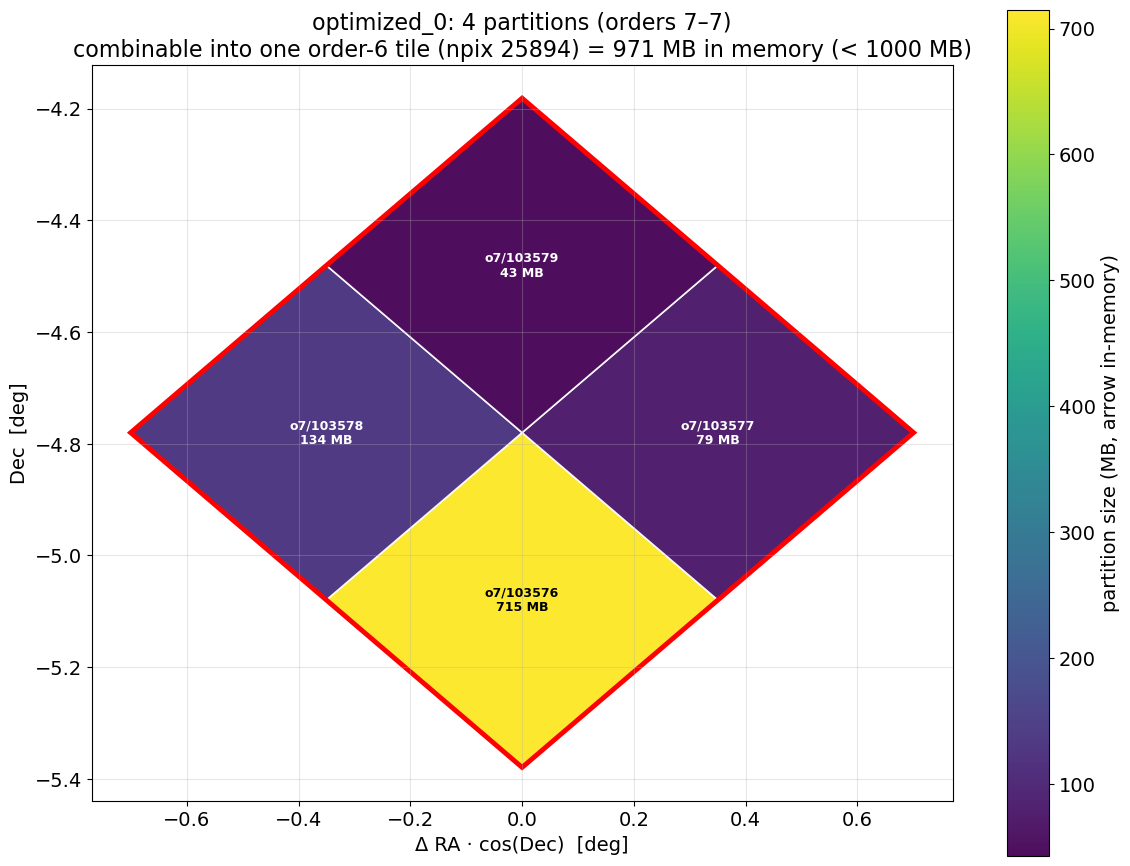

In [10]:
example_parent = ps.plot_merge_example("optimized_0", CATALOGS["optimized_0"],
                                       thresh_mb=MERGE_THRESH_MB)

### Where that region sits on the partition map

The same `example_parent` pixel marked (red tile) on the zoomed optimized_0 map.

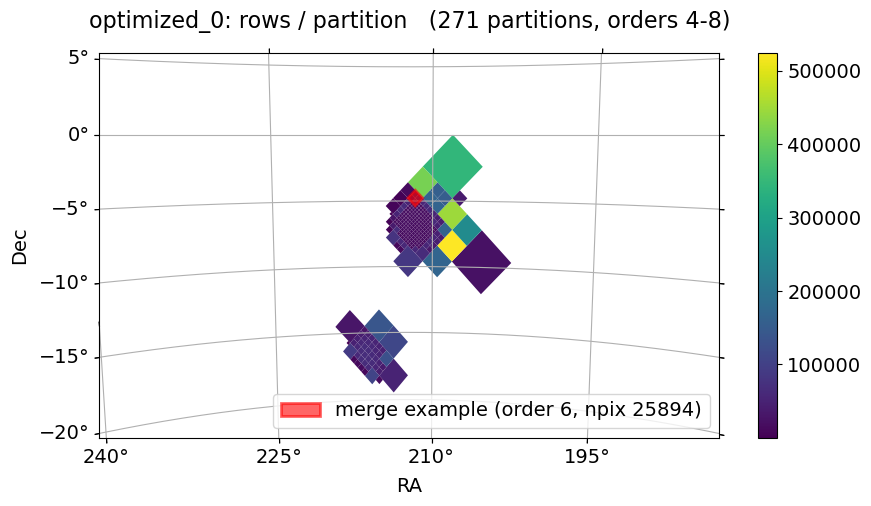

In [11]:
_ = ps.plot_partition_map("optimized_0", CATALOGS["optimized_0"],
                          by="rows", mark=example_parent)

# Conclusions

- All three builds **respect the 1 GB in-memory cap**: max partitions are 809 / 835 /
  869 MB arrow.
- Genuine over-splitting is small: **4.4% / 7.6% / 9.5%** of partitions could merge
  coarser. Every remaining merge group is a single-level 4-sibling collapse landing at
  **872–996 MB (87–100% of budget)** — parents the builder's estimator judged just over
  1 GB that came in just under when written, i.e. a small safety margin near the
  boundary, not a bug.
- The `hats_max_rows = 1M` cap never binds; the memory target is the active constraint.
- Judge mergeability only with exact arrow sizes: disk bytes understate RAM ~3×,
  parquet-uncompressed metadata ~1.5–2.3×.